### CSEC 720 Deep Learning Security - Experimentation Assignment 2

# <center>Poisoning Attacks and Backdoor Attacks</center>

### 1. Overview
The learning objective of this experimentation assignment is for students to understand poisoning and backdoor attacks and the corresponding defenses against these attacks, including how to perform label flipping poisoning attack and hidden trigger backdoor attack, and how to defend against these attacks using data sanitization.

#### Lecture notes.
Detailed coverage of these topics can be found in the following:
<li>Label Flipping Attacks</li>
<li>Poisoning Defenses</li>
<li>Hidden Trigger Backdoor Attacks</li>

#### Code demonstrations.
<li>Label Flipping Attack.ipynb</li>
<li>Data Sanitization.ipynb</li>
<li>Hidden Trigger Backdoor Attack.ipynb</li>

### 2. Submission
You need to submit a detailed lab report with code, running results, and detailed answers to all questions. If you submit <font color='red'>a jupyter notebook (“Firstname-Lastname-Exp2.ipynb”)</font>, please fill in this file directly and place the code, running results, and answers in order for each question. If you submit <font color='red'>a PDF report (“Firstname-Lastname-Exp2.pdf”) with code file (“Firstname-Lastname-Exp2.py”)</font>, please include the screenshots (code and running results) with detailed answers for each question in the PDF report. Please use your real <font color='red'>Firstname and Lastname</font> in the filenames.   

### 3. Questions (50 points)

#### Preparations: import the required libraries and define functions

Please run the following cell to import all the required libraries and define some necessary functions before complete the coding questions.

In [25]:
#Put all the libraries here
import numpy as np

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.parameter import Parameter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset, Dataset

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

import matplotlib as mpl
import matplotlib.pyplot as plt

#Set the random seed
np.random.seed(42)
torch.manual_seed(42)

#Define the training function for training model using train_dataloader
def train(epoch, model, train_dataloader, optimizer, lossfunction):
    model.train()

    train_loss = 0.0
    train_total, train_correct = 0.0, 0.0

    for X_batch, y_batch in train_dataloader:
        optimizer.zero_grad()

        #Get the predicted output
        predictions = model(X_batch)

        #Calculate the loss
        loss = lossfunction(predictions, y_batch)

        #Update the weights usning gradient descent with Adam optimizer
        loss.backward()
        optimizer.step()

        #Convert probabilities to multi-class predictions (reutrn the class with the maximal proability)
        _, train_predicted = torch.max(predictions.data, 1)

        #Calculate the training statistics
        train_loss += loss.item()
        train_total += y_batch.size(0)
        train_correct += (train_predicted == y_batch).sum().item()

    print("epoch (%d): Train accuracy: %.4f, loss: %.3f" % (epoch, train_correct/train_total, train_loss/train_total))

#Define the test function for evaluating the trained model using test_dataloader
def test(model, test_dataloader):
    model.eval()

    test_correct, test_total = 0.0, 0.0
    y_test, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_dataloader:
            predictions = model(X_batch)

            _, test_predicted = torch.max(predictions.data, 1)
            test_total += y_batch.size(0)
            test_correct += (test_predicted == y_batch).sum().item()

            y_test += y_batch.tolist()
            y_pred += test_predicted.tolist()

    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print('Test accuracy: %.4f, macro f1_score: %.4f' % (test_correct / test_total, macro_f1))

#Define the function that returns a predicted label for a single input sample
def predict_label(model, single_input):
    model.eval()
    with torch.no_grad():
        prediction = model(single_input)
        _, predicted_label = torch.max(prediction.data, 1)

    return predicted_label

#Define the function that convert the raw dataset to PyTorch tensor
class WrappedDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __getitem__(self, index):
        x, y = self.base_dataset[index]
        return x, torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.base_dataset)

#Define the function that returns model parameters
def weight_parameters(model):
    model.eval()
    with torch.no_grad():
        parameters = list(model.parameters())[0]

    return parameters.detach().squeeze()

#Define the function that plots the given images
def plot_digits(instances, labels, images_per_row=5):
    for i in range(len(instances)):
        idx = i // images_per_row
        idy = i % images_per_row
        ax[idx, idy].imshow(instances[i].squeeze())
        ax[idx, idy].set_title(class_names[labels[i]])
        ax[idx, idy].axis("off")

#Define the function to train a linear model and get y_hat for label flipping attack
def train_linear_model(epoch, linear_model, linear_model_optimizer, X, y, lossfunction):
    linear_model.train()
    linear_model_optimizer.zero_grad()
    linear_model_outputs = linear_model(X)
    linear_model_loss = -lossfunction(linear_model_outputs, y) #Need to place "-" before loss function
    linear_model_loss.backward()
    linear_model_optimizer.step()

    print('Epoch: {:d}'.format(epoch),
          'linear_model_loss: {:.4f}'.format(linear_model_loss.item()))

#Define the function to train a feature collision model for hidden trigger backdoor attack
def train_feature_collision_model(i, epoch, feature_collision_model, feature_collision_model_optimizer, triggered_instance, base_instance):
    feature_collision_model.train()
    feature_collision_model_optimizer.zero_grad()
    feature_collision_objective = feature_collision_model(triggered_instance, base_instance)
    feature_collision_objective.backward()
    feature_collision_model_optimizer.step()

## <font color='blue'>Label Flipping Attack</font>

#### Load and preprocess the `Breast Cancer Wisconsin dataset` data

In Question 1, Question 2, Question 3, and Question 4, you will be using the `Breast Cancer Wisconsin dataset` to train a logistic regression model (binary classification model) to predict whether a tumor is `0: malignant` or `1: benign`, and perform a label flipping poisoning attack against this trained binary classification model. First, please run the following cell to load and preprocess the dataset.

In [26]:
#Load breast cancer wisconsin dataset
cancer = load_breast_cancer()

#Assign features and labels to X and y
X, y = cancer.data, cancer.target

#Class names
print("Class names: ", cancer.target_names)
#Feature number
print("Number of Features: ", X.shape[1])

#Split the data into two sets: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

Class names:  ['malignant' 'benign']
Number of Features:  30
(455, 30)
(455,)
(114, 30)
(114,)


#### Question 1 (5 points):  

**Implement function `answer_one( )` to train a binary model `binary_model` using `(X_train, y_train)` from `Breast Cancer Wisconsin dataset`, and evaluate the model performance by calculating accuracy and F1 score.**

**To simplify the model training process, please directly use `LogisticRegression` from Scikit-learn library.**

In [27]:
def answer_one():
    #Write your code here:
    #Define a binary_model using LogisticRegression() from scikit-learn library
    binary_model = LogisticRegression(solver='newton-cg', random_state=42, max_iter=10000)
    #Call fit() to train binary_model using X_train and y_train
    binary_model.fit(X_train, y_train)
    #Use the trained model to predict on X_test to get y_pred
    y_pred = binary_model.predict(X_test)
    #Use y_test and y_pred to calculate accuracy and F1 score using sklearn functions
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return binary_model, accuracy, f1

#Run your function in the cell to return the results
binary_model, clean_accuracy, clean_f1 = answer_one()
print("Accuracy:", clean_accuracy)
print("F1:", clean_f1)

Accuracy: 0.956140350877193
F1: 0.9655172413793104


#### <font color='red'>Answer 1 (double click here to answer the questions in this cell):</font>  
Before label flipping attack
- The test accuracy is: ( 0.956140350877193 )  
- The test f1 score is: ( 0.9655172413793104 )

#### Question 2 (10 points):  
**Implement a label flipping attack to poison the labels of the training data `y_train`, such that the logistic regression model re-trained on the poisoned data would make misclassification and thus decrease its test accuracy.**

**First, define a class `LinearClassificationNet` to construct a linear classifier as sarrogate model to facilitate $\hat{y}$ optimization. After that, complete the function `answer_two( )` to use closed form solution to optimize lab flipping attack and obtain the flipping operation probabilities. The closed form of weight matrix is $W=(X^T\cdot X)^{-1}X^T\hat{y}$. Based on the weight matrix, the linear classifier can be fixed as $f_W(X) = X \cdot W = X \cdot (X^T\cdot X)^{-1}X^T\hat{y}$, where $\hat{y}$ is the only parameter in the function. $\hat{y}$ represents flipping operation probabilities to specify how possible a specified label should be flipped to 1.**

In [28]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

train_num = X_train.shape[0]

epochs = 50
learning_rate = 0.01
weight_decay = 5e-4
lossfunction = nn.BCEWithLogitsLoss()

#Define a class LinearClassificationNet to construct a linear classifier using closed form
class LinearClassificationNet(nn.Module):
    def __init__(self, train_num):
        super(LinearClassificationNet, self).__init__()
        #Write your code here:
        #Define self.y_hat as label flipping probability tensor with size of (train_num, 1)
        self.y_hat = torch.ones((train_num, 1), dtype=torch.float32)
        #Initialize self.y_hat as 0.5 (multiply 0.5 with the tensor)
        self.y_hat = self.y_hat * 0.5
        #Add self.y_hat to the model parameter (requires_grad needs to be True)
        self.y_hat = nn.Parameter(self.y_hat, requires_grad=True)

    def closedform(self, x):
        x_t = torch.transpose(x, 0, 1)
        x_x = torch.mm(x_t, x)               #X^T.X
        x_x_1 = torch.inverse(x_x)           #(X^T.X)^-1
        x_x_1_t = torch.mm(x_x_1, x_t)       #(X^T.X)^-1.X^T

        return torch.mm(x_x_1_t, self.y_hat) #(X^T.X)^-1.X^T.y_hat

    def forward(self, x):
        #Write your code here:
        #Call self.closedform() to get the closed form of w
        w = self.closedform(x)
        #Calculate the output of the linear classifier (y = x.w)
        y = torch.mm(x, w)

        return y


def answer_two():
    #Write your code here:
    #Instantiate a linear_model from the defined LinearClassificationNet (need to pass a corresponding parameter train_num)
    linear_model = LinearClassificationNet(train_num)
    #Specify the Adam optimizer (parameters, learning_rate, and weight_decay) used for linear_model training via gradient descent
    lm_optimizer = optim.Adam(linear_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    #Call train_linear_model() function in a for loop with epochs for model training: you need to pass the corresponding parameters to this function and training data is (X_train_tensor, y_train_tensor)
    for epoch in range(epochs):
      train_linear_model(epoch, linear_model, lm_optimizer, X_train_tensor, y_train_tensor, lossfunction)
    #Call weight_parameters() function to extract the linear_model parameter and assign it to y_hat
    y_hat = weight_parameters(linear_model)
    #Convert y_hat to the label flipping probabilities by normalizing it to [0, 1] using nn.Sigmoid()()
    y_hat = nn.Sigmoid()(y_hat)

    return y_hat

#Run your function in the cell to return the results
y_hat = answer_two()
print("Y_Hat: ", y_hat)

Epoch: 0 linear_model_loss: -0.6607
Epoch: 1 linear_model_loss: -0.6643
Epoch: 2 linear_model_loss: -0.6679
Epoch: 3 linear_model_loss: -0.6715
Epoch: 4 linear_model_loss: -0.6752
Epoch: 5 linear_model_loss: -0.6788
Epoch: 6 linear_model_loss: -0.6825
Epoch: 7 linear_model_loss: -0.6862
Epoch: 8 linear_model_loss: -0.6899
Epoch: 9 linear_model_loss: -0.6936
Epoch: 10 linear_model_loss: -0.6974
Epoch: 11 linear_model_loss: -0.7011
Epoch: 12 linear_model_loss: -0.7049
Epoch: 13 linear_model_loss: -0.7087
Epoch: 14 linear_model_loss: -0.7125
Epoch: 15 linear_model_loss: -0.7164
Epoch: 16 linear_model_loss: -0.7202
Epoch: 17 linear_model_loss: -0.7241
Epoch: 18 linear_model_loss: -0.7280
Epoch: 19 linear_model_loss: -0.7319
Epoch: 20 linear_model_loss: -0.7359
Epoch: 21 linear_model_loss: -0.7398
Epoch: 22 linear_model_loss: -0.7438
Epoch: 23 linear_model_loss: -0.7478
Epoch: 24 linear_model_loss: -0.7518
Epoch: 25 linear_model_loss: -0.7558
Epoch: 26 linear_model_loss: -0.7598
Epoch: 27 l

#### <font color='red'>Answer 2 (double click here to answer the questions in this cell):</font>  
- Based on the implemented attack steps, please briefly summarize the function the closed form solution performs in the label flipping attack: ( The closed form serves as a shortcut that links potential label changes to the classifier's behavior. This means the model doesn't have to be retrained repeatedly. It allows us to understand how changing specific labels impacts predictions. This makes it simpler to identify which changes will lead to the most errors. Technically speaking, it computes the weight matrix using $W=(X^T\cdot X)^{-1}X^T\hat{y}$, which means the model outputs become a direct function of y hat. This allows the attack to calculate a loss and take gradients with respect to the label probabilities, turning them into flipping chances through a sigmoid. The highest probability labels are then flipped within the given budget. This way the closed form makes the whole process faster and more efficient while clearly showing how each possible label flip influences the classifier’s performance. )

#### Question 3 (8 points):

**Implement the function `answer_three( )` for label flipping and attack performance evaluation. As $\hat{y}$ specifies how possible a label should be flipped to 1, here you need to select the top training samples with the largest probabilities to perform label flipping. The maximum number of training samples you can poison is constrained as `epsilon`. After label flipping attack, please use the poisoned training data to retrain logistic regression model and evaluate its classification accuracy on the test data.**  

**Set `epsilon=` using `30`, `60`, `90` respectively to evaluate how `epsilon` impacts on the attack performance.**

In [29]:
#epsilon: the number of labels to flip
#Write your code here: set epsilon as 30, 60, and 90, respectively
epsilon = [30, 60, 90]

def answer_three(epsilon):
    flipped_labels = y_train.copy()
    #Write your code here:
    #Extract indices whose probabilities are sorted in descending order by y_hat values (pay attention to the order)
    indices = torch.argsort(y_hat, descending=True)

    cnt = 0

    for idx in indices:
        #Write your code here:
        #Select the training samples with the largest probabilities and flip them to 1
        #(the number of flipped labels do not include the training labels whose original labels are 1)
        if flipped_labels[idx] != 1 and y_hat[idx] > 0.5:
          flipped_labels[idx] = 1
          cnt += 1
          if cnt == epsilon:
            break

    #Write your code here:
    #Define a new poisoned_binary_model using LogisticRegression() from scikit-learn library
    poisoned_binary_model = LogisticRegression(solver='newton-cg', random_state=42, max_iter=10000)
    #Call fit() to train poisoned_binary_model using X_train and flipped_labels
    poisoned_binary_model.fit(X_train, flipped_labels)
    #Use the trained poisoned_binary_model to predict on X_test to get y_pred_poisoned
    y_pred_poisoned = poisoned_binary_model.predict(X_test)
    #Use y_test and y_pred_poisoned to calculate accuracy and F1 score using sklearn functions
    accuracy_poisoned = accuracy_score(y_test, y_pred_poisoned)
    f1_poisoned = f1_score(y_test, y_pred_poisoned)

    return flipped_labels, accuracy_poisoned, f1_poisoned

#Run your function in the cell to return the results
results = {}
for eps in epsilon:
    flipped_labels, accuracy_poisoned, f1_poisoned = answer_three(eps)
    results[eps] = (accuracy_poisoned, f1_poisoned)
    print(f"Epsilon {eps} Results, accuracy {accuracy_poisoned:.4f}, f1 {f1_poisoned:.4f}")

Epsilon 30 Results, accuracy 0.9211, f1 0.9396
Epsilon 60 Results, accuracy 0.8070, f1 0.8642
Epsilon 90 Results, accuracy 0.6667, f1 0.7889


#### <font color='red'>Answer 3 (double click here to answer the questions in this cell):</font>
After label flipping attack
- When epsilon = 30, the test accuracy is: ( 0.9211 ) and the f1 score is: ( 0.9396 )
- When epsilon = 60, the test accuracy is: ( 0.8070 ) and the f1 score is: ( 0.8642 )
- When epsilon = 90, the test accuracy is: ( 0.6667 ) and the f1 score is: ( 0.7889 )
- Compared to the test performance before attack, please describe your observation: ( After the label flipping attack, we see a clear decline in both accuracy and F1 score compared to the model's performance before the attack. As more incorrect labels were added, the model's ability to correctly classify test samples decreased. This demonstrates that the attack directly harmed how well the model learned from the training data. )
- Summarize the impact of epsilon on the label flipping attack performance: ( When epsilon increased, the model’s accuracy and F1 score steadily went down. A small epsilon caused only minor performance changes, but larger values made the model more confused because of the higher number of flipped labels. This means that the strength of the attack grows with epsilon, leading to a greater drop in prediction quality and overall performance. )

## <font color='blue'>Data Sanitization against Label Flipping Attack</font>

#### Question 4 (7 points):  
**Implement the function `answer_four( )` to build a k-Nearest Neighbors (kNN) using clean data `(X_train, y_train)` to sanitize the poisoned training data `(X_train, flipped_labels)` and mitigate the effect of label flipping attack on the test data. After removing those potential poisoned training samples, all the remaining samples can be constructed as the new and sanitized training data for the new logistic regression model training.**

In [30]:
def answer_four():
    #Write your code here:
    #Build a kNN model using scikit-learn library KNeighborsClassifier with 5 nearest neighbors
    KNN_Model = KNeighborsClassifier(n_neighbors=5)
    #Call fit() to train this kNN model using X_train and y_train
    KNN_Model.fit(X_train, y_train)

    #Write your code here:
    #Use the kNN model to predict the labels for all training samples in X_train and get y_pred_knn
    y_pred_knn = KNN_Model.predict(X_train)

    #Write your code here:
    #Get the mask for all samples that are (flipped_labels == y_pred_knn)
    #Assign the masked samples from (X_train, flipped_labels) to (X_sanitized, y_sanitized)
    mask = (flipped_labels == y_pred_knn)
    X_sanitized = X_train[mask]
    y_sanitized = flipped_labels[mask]

    #Write your code here:
    #Define a new sanitized_binary_model using LogisticRegression() from scikit-learn library
    clean_binary_model = LogisticRegression(solver='newton-cg', random_state=42, max_iter=10000)
    #Call fit() to train sanitized_binary_model using X_sanitized and y_sanitized
    clean_binary_model.fit(X_sanitized, y_sanitized)
    #Use the trained sanitized_binary_model to predict on X_test to get y_pred_sanitized
    y_pred_clean = clean_binary_model.predict(X_test)
    #Use y_test and y_pred_sanitized to calculate accuracy and F1 score using sklearn functions
    accuracy_sanitized = accuracy_score(y_test, y_pred_clean)
    f1_sanitized = f1_score(y_test, y_pred_clean)

    return accuracy_sanitized, f1_sanitized

#Run your function in the cell to return the results
accuracy_sanitized, f1_sanitized = answer_four()
print("Accuracy: ", accuracy_sanitized)
print("F1: ", f1_sanitized)


Accuracy:  0.956140350877193
F1:  0.9659863945578231


#### <font color='red'>Answer 4 (double click here to answer the questions in this cell):</font>
After data sanitization
- The test accuracy is: ( 0.956140350877193 )
- The f1 score is: ( 0.9659863945578231 )
- Compared to the test performance in Question 3, please describe the difference: ( After data sanitization, both the test accuracy and F1 score improved and nearly matched the results of the clean model. This shows that the label flipping attack's effects were removed. The model could learn the correct relationships between features and labels again without being misled by poisoned samples. In other words, the sanitization step restored the dataset's quality and brought the model's performance back to its original state before the attack. )
- Briefly explain why data sanitization can be used to defend against poisoning attack: ( Data sanitization acts as a defense by closely checking the training data to identify and fix any poisoned or questionable labels. In a label flipping attack, some samples are deliberately mislabeled to mislead the model. Sanitization detects these inconsistencies using measures such as model confidence, prediction consistency, or distance from class boundaries. By fixing or removing the corrupted samples, the training set is clean again. This helps the model learn the right patterns and prevents the attacker’s changes from affecting prediction performance. )

## <font color='blue'>Hidden Trigger Backdoor Attack</font>

#### Load and preprocess the `Fashion-MNIST` data

In Question 5 and Question 6, you will be using the `Fashion-MNIST` to train a convolutional neural network model to predict the fashion product name of a given image, and perform backdoor attacks against this trained fashion product image classification model. First, download the `Fashion-MNIST` data directly from PyTorch and convert the dataset into Tensor used by PyTorch.

Loading `Fashion-MNIST` data of 70,000 images may take some time. The downloaded `Fashion-MNIST` data file will be stored in  `data` folder under the same directory with your notebook/python file.

The size of each image in `Fashion-MNIST` data is 28x28. Each image is fed as 28x28 matrix to convolutional neural network directly.

**For simplicity, you will only use 500 images for training and 50 images for testing**

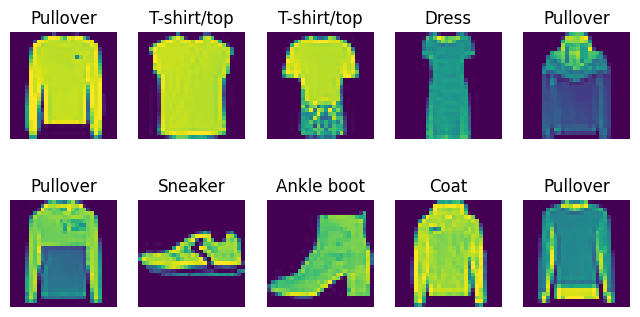

In [31]:
torch.manual_seed(42)

#Convert the dataset into Tensor used by PyTorch
transform=transforms.Compose([
         transforms.ToTensor(),
        ])

#Download the Fashion-MNIST data directly from PyTorch
#The downloaded datasets are stored in data folder under the same folder with this jupyter notebook file
train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# Create subset indices
train_subset_size = 500
test_subset_size = 50
train_subset_indices = torch.randperm(len(train_dataset))[:train_subset_size]
test_subset_indices = torch.randperm(len(test_dataset))[:test_subset_size]

# Create subset dataset
train_subset = Subset(train_dataset, train_subset_indices)
test_subset = Subset(test_dataset, test_subset_indices)

#Load the datasets into DataLoader
train_dataloader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_subset, batch_size=64, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#Plot some Fashion-MNIST examples
dataiter = iter(train_dataloader)
samples = next(dataiter)
fig, ax = plt.subplots(2, 5, figsize=(8, 4))
example_images = samples[0][:10]
example_labels = samples[1][:10]
plot_digits(example_images, example_labels, images_per_row=5)
plt.show()

#### Pre-train a convolutional neural network using `Fashion-MNIST` data

In the following questions, you will focus on performing and evaluating hidden trigger backdoor attack; therefore, directly run the following unit to pre-trained a CNN model.

In [32]:
#Pre-define the CNN clsss for image classification
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#Set up some hyperparameters
torch.manual_seed(2)
epochs = 10
learning_rate = 0.01
weight_decay = 5e-4
lossfunction = nn.CrossEntropyLoss()
clean_model = CNN()
clean_optimizer = optim.Adam(clean_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

#Train the clean model
for epoch in range(1, epochs + 1):
    train(epoch, clean_model, train_dataloader, clean_optimizer, lossfunction)

#Test the clean model
test(clean_model, test_dataloader)

epoch (1): Train accuracy: 0.2260, loss: 0.033
epoch (2): Train accuracy: 0.4720, loss: 0.021
epoch (3): Train accuracy: 0.6180, loss: 0.016
epoch (4): Train accuracy: 0.6480, loss: 0.015
epoch (5): Train accuracy: 0.6860, loss: 0.012
epoch (6): Train accuracy: 0.7140, loss: 0.011
epoch (7): Train accuracy: 0.7420, loss: 0.010
epoch (8): Train accuracy: 0.7580, loss: 0.010
epoch (9): Train accuracy: 0.7700, loss: 0.009
epoch (10): Train accuracy: 0.7820, loss: 0.009
Test accuracy: 0.8200, macro f1_score: 0.7815


#### Construct base instances (base label c) and target instances (across all labels that are different from c) for backdoor attacks

-------Base instances-------


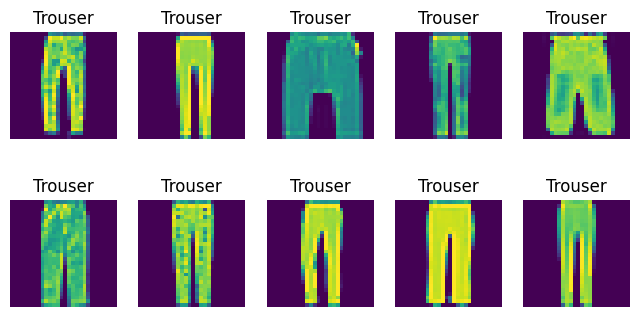

-------Target instances-------


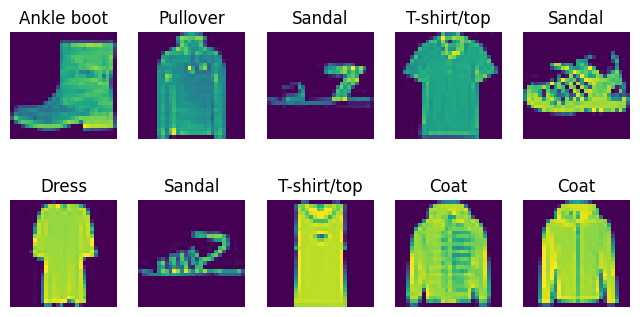

In [33]:
#Choose a base label: all the images with trojan trigger should be classified as this label
base_label_name = 'Trouser'
base_label_index = class_names.index(base_label_name)

#Obtain all the target instances and base instances
target_instances = []  #Instances with target_label (target_label is the label that is different from base_label)
target_labels = []
base_instances = []    #Instances with base_label
base_labels = []

for samples, labels in train_subset:
    if labels == base_label_index:
        base_instances.append(samples)
        base_labels.append(labels)
    if labels != base_label_index:
        target_instances.append(samples)
        target_labels.append(labels)

target_instances = torch.stack(target_instances)
base_instances = torch.stack(base_instances)

#Plot some base instances
print("-------Base instances-------")
fig, ax = plt.subplots(2, 5, figsize=(8, 4))
example_images = base_instances[:10]
example_labels = base_labels[:10]
plot_digits(example_images, example_labels, images_per_row=5)
plt.show()

print("-------Target instances-------")
#Plot some target instances
fig, ax = plt.subplots(2, 5, figsize=(8, 4))
example_images = target_instances[:10]
example_labels = target_labels[:10]
plot_digits(example_images, example_labels, images_per_row=5)
plt.show()

#### Question 5 (10 points):  
**Please implement a hidden trigger backdoor attack that first adds trojan trigger patten to the target images, and then perturbs the base images toward the target images with trojan trigger to generate the perturbed images, where these perturbed images are the final poisoned images. Afterwards, injects these poisoned images into the training data `train_subset`, such that the CNN model re-trained on the poisoned data would correctly classify the test images without trojan trigger, but misclassify the test images with trojan trigger as the base label `base_label_name`.**

**First, define `FeatureCollisionNet` to construct a feature collision class to facilitate the optimization of the perturbed images. Then, implement the function `answer_five( )` to add trojan trigger to the target images, and use feature collision to generate the perturbed images. Feature collision can be formalized as an optimization problem $x = min \|f(x) - f(x_t)\|^2_2 + \beta\|x - x_c)\|^2_2$, where $f(\cdot)$ is a neural network used to learn the task-specific features of an input image, $x_t$ is a target image, and $x_c$ is a base image. You can use the clean convoutional neural network `clean_model` pre-trained in the previous unit as the neural network to learn the task-specific features. By minimizing $\|f(x) - f(x_t)\|^2_2 + \beta\|x - x_c)\|^2_2$, the optimal $x$ can be extracted as the perturbed images.**  

**Set `beta=` using `1`, `5`, respectively to evaluate how `beta` impacts on the feature collision from base instance and target instance.**

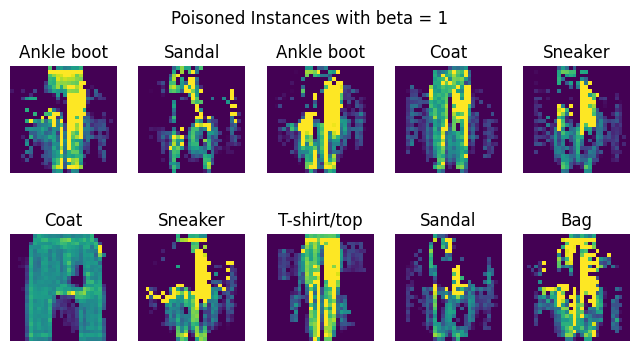

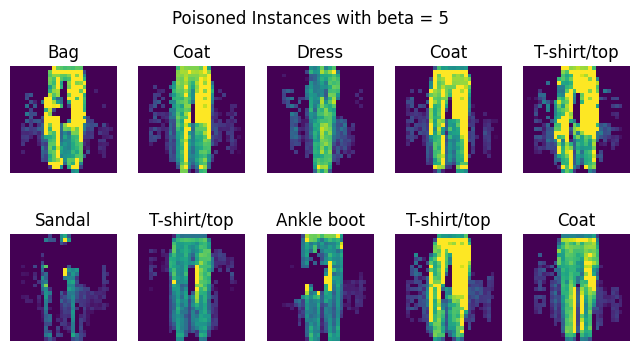

In [34]:
torch.manual_seed(42)
epochs = 50
learning_rate = 0.1
poisoned_account = 50

trojan_trigger = torch.Tensor([[1.]]).repeat(14, 8)

#Write your code here:
#Set beta as 1, 5, respectively
beta = [1, 5]

#Define a class FeatureCollisionNet to construct the objective function for feature collision operation
class FeatureCollisionNet(nn.Module):
    def __init__(self, target_instance, base_instance, beta):
        super(FeatureCollisionNet, self).__init__()
        #Write your code here:
        #Define self.x and initialize it as a base_instance using clone
        #Add self.x to the model parameter (requires_grad needs to be True)
        self.x = nn.Parameter(base_instance.clone().detach(), requires_grad=True)

        self.beta = beta

        self.pretrained_model = clean_model
        self.pretrained_model.eval()
        for param in self.pretrained_model.parameters():
            param.requires_grad = False

    def get_task_specific_features(self, input_instance):
        output = self.pretrained_model(input_instance)
        return output

    def forward(self, target_instance, base_instance):
        x = torch.clamp(self.x, 0, 1)

        #Write your code here:
        #Call self.get_task_specific_features() to extract the task-specific features for x
        task_specific_x = self.get_task_specific_features(x)

        #Write your code here:
        #Call self.get_task_specific_features() to extract the task-specific features for target_instance
        task_specific_target = self.get_task_specific_features(target_instance)

        #Feature collision is to minimize an objective function: ||f(x) - f(x_t)||^2 + beta||x - x_c)||^2

        #Write your code here:
        #construct the objective function for feature collision
        objective = torch.sum((task_specific_x - task_specific_target) ** 2) + self.beta * torch.sum((x - base_instance) ** 2)

        return objective


def answer_five(beta):
    triggered_instances = target_instances.clone()
    triggered_instances[:, 0, :14, :8] = trojan_trigger

    poisoned_instances = []

    for i in range(poisoned_account):
        #Write your code here:
        #Randomly select one triggered instance from triggered_instances
        triggered_instance = triggered_instances[torch.randint(0, len(triggered_instances), (1,))]
        #Write your code here:
        #Randomly select one base instance from base_instances
        base_instance = base_instances[torch.randint(0, len(base_instances), (1,))]

        parameter_to_update = []

        #Write your code here:
        #Instantiate a feature_collision_model from the defined FeatureCollisionNet (need to pass three parameters)
        feature_collision_model = FeatureCollisionNet(triggered_instance, base_instance, beta)

        for p in feature_collision_model.parameters():
            if p.requires_grad:
                parameter_to_update.append(p)
                break

        #Write your code here:
        #Specify the Adam optimizer (parameter_to_update, learning_rate) used for model training via gradient descent
        feature_collision_model_optimizer = torch.optim.Adam(parameter_to_update, lr=learning_rate)

        #Write your code here:
        #Call train_feature_collision_model() function in a for loop with epochs for training: you need to pass the corresponding parameters to this function
        for epoch in range(epochs):
          train_feature_collision_model(i, epoch, feature_collision_model, feature_collision_model_optimizer, triggered_instance, base_instance)

        poisoned_instances.append(torch.clamp(parameter_to_update[0].squeeze(0), 0, 1))

    poisoned_instances = torch.stack(poisoned_instances)

    return poisoned_instances.detach()


for b in beta:
  #Run your function in the cell to return the results
  poisoned_instances = answer_five(b)

  #Plot some poisoned instances: the instances should look like the base instance (Trouser)
  #but their task-specific features are closer to the target instances with trigger (tend to be predicted as target labels)
  poisoned_predicted = predict_label(clean_model, poisoned_instances)
  fig, ax = plt.subplots(2, 5, figsize=(8, 4))
  example_images = poisoned_instances[:10]
  example_labels = poisoned_predicted[:10]
  plot_digits(example_images, example_labels, images_per_row=5)
  plt.suptitle(f"Poisoned Instances with beta = {b}")
  plt.show()

#### <font color='red'>Answer 5 (double click here to answer the questions in this cell):</font>
Hidden trigger backdoor attack is to perturb the base images towards the target images with trojan trigger, where the perturbed images look like the base instances but get closer to task-specific features of the target instances with trojan trigger. In this question, the base label is "Trousers".
- Based on the perturbed images plotted above, please submmarize how `beta` with different values (`1` and `5`) impacts on the looks of the perturbed images and their relationships with base images and target images: ( From the poisoned images, the value of beta clearly affects how much the perturbed images resemble the base instances. When beta = 1, the optimization puts more focus on making the features of the poisoned images close to the target instances with the trojan trigger. This makes the changes stronger and a bit more noticeable, so the images drift further from the clean “Trouser” look. When beta equals 5, the regularization term becomes stronger. This keeps the altered images more similar to the original base samples. As a result, the images resemble the clean "Trousers" more closely and show fewer visible changes. However, their internal features still move toward the target class. )

- Based on the perturbed images plotted above, you cannot spot the trojan trigger pattern. Please explain why: ( The trojan trigger pattern is not visible because the perturbations created by the attack happen in the feature space rather than the pixel space. The optimization changes subtle pixel values that influence how the model perceives the features, but these changes are small and spread across the image instead of forming a distinct visible mark. This makes the trigger hidden from human eyes even though the model learns to associate it with the target label, allowing the attack to remain stealthy. )

#### Question 6 (10 points):

**Implement the function `answer_six( )` to add the poisoned images to the training data and retrain the CNN model to evaluate the hidden trigger backdoor attack performance, including the accuracy on the test images without trojan trigger and the accuracy on the test images with trojan trigger.**

In [35]:
torch.manual_seed(42)
epochs = 10
learning_rate = 0.01
weight_decay = 5e-4
lossfunction = nn.CrossEntropyLoss()

def answer_six():
    poisoned_labels = torch.full((poisoned_account,), base_label_index, dtype=torch.long)

    #Write your code here:
    #Call TensorDataset() to construct poisoned_dataset using (poisoned_instances, poisoned_labels)
    poisoned_dataset = torch.utils.data.TensorDataset(poisoned_instances, poisoned_labels)

    train_subset_wrapped = WrappedDataset(train_subset)

    #Write your code here:
    #Call ConcatDataset() to construct poisoned_train_dataset by concatenating train_subset_wrapped and poisoned_dataset
    poisoned_train_dataset = torch.utils.data.ConcatDataset([train_subset_wrapped, poisoned_dataset])

    #Write your code here:
    #Call DataLoader() to load poisoned_train_dataset into DataLoader (specify batch_size and shuffle needs to be true)
    poisoned_train_dataloader = torch.utils.data.DataLoader(poisoned_train_dataset, batch_size=64, shuffle=True)

    #Write your code here:
    #Instantialize a backdoor_model from the defined CNN class
    backdoor_model = CNN()

    #Write your code here:
    #Specify the Adam optimizer (parameters, learning_rate, and weight_decay) used for backdoor_model training via gradient descent
    backdoor_optimizer = torch.optim.Adam(backdoor_model.parameters(), lr=learning_rate, weight_decay=1e-4)

    print("-------Training a backdoor model using the poisoned images-------")
    for epoch in range(1, epochs + 1):
        #Write your code here:
        #Call train() function for backdoor_model training
        #Note: the model, optimizer, and dataloader should be backdoor model/optimizer and poisoned_train_dataloader
        train(epoch, backdoor_model, poisoned_train_dataloader, backdoor_optimizer, lossfunction)


    print("-------Test the backdoor_model on the clean test data-------")
    #Write your code here:
    #Call test() function for testing on clean data
    #Note: the model should be backdoor model, and the clean test data should be test_dataloader
    test(backdoor_model, test_dataloader)


    print("-------Test the backdoor_model on the poisoned test data with trojan trigger-------")
    test_instances = []
    test_labels = []

    for samples, labels in test_subset:
        if labels != base_label_index:
            backdoor_test_instances = samples.clone()
            backdoor_test_instances[0, :14, :8] = trojan_trigger
            test_instances.append(backdoor_test_instances)
            test_labels.append(labels)

    test_instances = torch.stack(test_instances)
    test_labels = torch.tensor(test_labels)

    #Write your code here:
    #Call TensorDataset() to construct backdoor_test_dataset using (test_instances, test_labels)
    backdoor_test_dataset = TensorDataset(test_instances, test_labels)

    #Write your code here:
    #Call DataLoader() to load backdoor_test_dataset into DataLoader (specify batch_size and shuffle needs to be false)
    backdoor_test_dataloader = DataLoader(backdoor_test_dataset, batch_size=64, shuffle=False)

    #Write your code here:
    #Call test() function for testing on backdoored data
    #Note: the model should be backdoor model, and the test data should be backdoor_test_dataloader
    test(backdoor_model, backdoor_test_dataloader)

#Run your function in the cell to return the results
answer_six()

-------Training a backdoor model using the poisoned images-------
epoch (1): Train accuracy: 0.2455, loss: 0.035
epoch (2): Train accuracy: 0.5182, loss: 0.020
epoch (3): Train accuracy: 0.6600, loss: 0.015
epoch (4): Train accuracy: 0.6655, loss: 0.014
epoch (5): Train accuracy: 0.7236, loss: 0.011
epoch (6): Train accuracy: 0.7527, loss: 0.010
epoch (7): Train accuracy: 0.7691, loss: 0.010
epoch (8): Train accuracy: 0.7873, loss: 0.009
epoch (9): Train accuracy: 0.8109, loss: 0.008
epoch (10): Train accuracy: 0.8400, loss: 0.007
-------Test the backdoor_model on the clean test data-------
Test accuracy: 0.7400, macro f1_score: 0.7156
-------Test the backdoor_model on the poisoned test data with trojan trigger-------
Test accuracy: 0.5111, macro f1_score: 0.3293


#### <font color='red'>Answer 6 (double click here to answer the questions in this cell):</font>
When testing the backdoor model on the test data without trojan trigger
- The test accuracy is: ( 0.7400 ), f1 score is: ( 0.7156 )

When testing the backdoor model on the test data with trojan trigger
- The test accuracy is: ( 0.5111 ), f1 score is: ( 0.3293 )

Based on these test performances
- Please describe your observation on hidden trigger backdoor attack: ( The model keeps reasonable performance on clean test data, accuracy about 0.74 and F1 about 0.72, but performance drops noticeably when the trojan trigger is added, accuracy falling to about 0.51 and F1 to about 0.33. This means the poisoned training caused the model to change its internal features so that adding the hidden trigger to otherwise normal images makes the model behave differently, producing more wrong predictions. At the same time the model still works fairly well on clean data, so the backdoor is active only when the trigger is present. )
- Summarize the advantage and disadvantage of hidden trigger backdoor attack regarding the visibility of its generated poisoned instances and the attack performance: (
  
Advantage: The hidden trigger backdoor creates poisoned images that appear normal to humans. However, when the trigger appears, it makes the model vulnerable. This allows the attack to be stealthy and difficult to catch through simple visual checks. The model also maintains good accuracy with clean data, so the backdoor can stay hidden during routine evaluations.

Disadvantage: The attack performance with the trigger might not be perfect. Achieving a strong backdoor often needs careful adjustment and a large number of poisoned examples. Additionally, the need for stealth forces subtle changes, which can reduce the attack's effectiveness. Defenses that check how features behave or use data cleaning can still find or eliminate poisoned samples. )